## 1. Exploration du dataset

In [12]:
import pandas as pd

df_test = pd.read_csv(
    r"C:\econometrie2\projet S2\baseprojetperso.csv",
    sep="\t",
    nrows=50,
    low_memory=False,
    on_bad_lines='skip'
)
 
print(df_test.shape)
print(df_test.columns.tolist())

(50, 209)
['code', 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime', 'last_modified_by', 'last_updated_t', 'last_updated_datetime', 'product_name', 'abbreviated_product_name', 'generic_name', 'quantity', 'packaging', 'packaging_tags', 'packaging_fr', 'packaging_text', 'brands', 'brands_tags', 'brands_fr', 'categories', 'categories_tags', 'categories_fr', 'origins', 'origins_tags', 'origins_fr', 'manufacturing_places', 'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_fr', 'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places', 'stores', 'countries', 'countries_tags', 'countries_fr', 'ingredients_text', 'ingredients_tags', 'ingredients_analysis_tags', 'allergens', 'allergens_fr', 'traces', 'traces_tags', 'traces_fr', 'serving_size', 'serving_quantity', 'no_nutrition_data', 'additives_n', 'additives', 'additives_tags', 'additives_fr', 'nutriscore_score', 'nutriscore_grade', 'nova_grou

## 2. Filtrage des produits français

In [15]:
import pandas as pd

cols_utiles = [
    'code', 'product_name', 'brands', 'quantity',
    'categories_fr', 'main_category_fr', 'pnns_groups_1', 'pnns_groups_2',
    'countries_fr', 'origins_fr', 'manufacturing_places',
    'nutriscore_grade', 'nutriscore_score', 'nova_group',
    'environmental_score_grade', 'additives_n',
    'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
    'carbohydrates_100g', 'sugars_100g', 'fiber_100g',
    'proteins_100g', 'salt_100g',
    'unique_scans_n', 'completeness'
]

chunks = []
for chunk in pd.read_csv(
    r"C:\econometrie2\projet S2\baseprojetperso.csv",
    sep="\t",
    usecols=cols_utiles,
    low_memory=False,
    on_bad_lines='skip',
    chunksize=100000
):
    chunk_fr = chunk[chunk['countries_fr'].str.contains('France', na=False)]
    chunks.append(chunk_fr)
    print(f"Chunk traité : {len(chunk_fr)} produits français trouves")

df_fr = pd.concat(chunks, ignore_index=True)
print(f"Total : {len(df_fr)} produits français")

df_fr.to_csv(r"C:\econometrie2\projet S2\projetalleger.csv", index=False)
print("Fichier sauvegarde : projetalleger")

Chunk traité : 9336 produits français trouves
Chunk traité : 5365 produits français trouves
Chunk traité : 2995 produits français trouves
Chunk traité : 5129 produits français trouves
Chunk traité : 3743 produits français trouves
Chunk traité : 33621 produits français trouves
Chunk traité : 44305 produits français trouves
Chunk traité : 13777 produits français trouves
Chunk traité : 6232 produits français trouves
Chunk traité : 5245 produits français trouves
Chunk traité : 2770 produits français trouves
Chunk traité : 13990 produits français trouves
Chunk traité : 40764 produits français trouves
Chunk traité : 34584 produits français trouves
Chunk traité : 39037 produits français trouves
Chunk traité : 49687 produits français trouves
Chunk traité : 90177 produits français trouves
Chunk traité : 96043 produits français trouves
Chunk traité : 93676 produits français trouves
Chunk traité : 93523 produits français trouves
Chunk traité : 93150 produits français trouves
Chunk traité : 97038 

## 3. Nettoyage et renommage des colonnes

In [16]:
import pandas as pd

df = pd.read_csv(r"C:\econometrie2\projet S2\projetalleger.csv")
print(f"Fichier charge : {df.shape}")

df = df.rename(columns={
    'code'                      : 'code_barre',
    'product_name'              : 'nom_produit',
    'brands'                    : 'marque',
    'quantity'                  : 'quantite',
    'categories_fr'             : 'categories',
    'main_category_fr'          : 'categorie_principale',
    'pnns_groups_1'             : 'groupe_alimentaire_1',
    'pnns_groups_2'             : 'groupe_alimentaire_2',
    'countries_fr'              : 'pays',
    'origins_fr'                : 'origine_ingredients',
    'manufacturing_places'      : 'lieu_fabrication',
    'nutriscore_grade'          : 'nutriscore',
    'nutriscore_score'          : 'nutriscore_points',
    'nova_group'                : 'transformation',
    'environmental_score_grade' : 'ecoscore',
    'additives_n'               : 'nb_additifs',
    'energy-kcal_100g'          : 'calories',
    'fat_100g'                  : 'graisses',
    'saturated-fat_100g'        : 'graisses_saturees',
    'carbohydrates_100g'        : 'glucides',
    'sugars_100g'               : 'sucres',
    'fiber_100g'                : 'fibres',
    'proteins_100g'             : 'proteines',
    'salt_100g'                 : 'sel',
    'unique_scans_n'            : 'nb_scans',
    'completeness'              : 'completude'
})
print("Colonnes renommées")
print(df['nutriscore'].value_counts())
print(df['transformation'].value_counts())
print((df.isnull().sum() / len(df) * 100).round(1).sort_values(ascending=False).head(15))

df.to_csv(r"C:\econometrie2\projet S2\projetalleger.csv", index=False)
print("Fichier sauvegarde")

C:\Users\remim\AppData\Local\Temp\ipykernel_27696\2384007523.py:3: DtypeWarning: Columns (0,8,9,11,15,16,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\econometrie2\projet S2\projetalleger.csv")


Fichier charge : (1253593, 26)
Colonnes renommées
nutriscore
unknown           704789
e                 133703
d                 125116
c                  97968
a                  64504
b                  52196
not-applicable     42245
Italie                 1
Name: count, dtype: int64
transformation
4.0       190374
3.0        69199
1.0        42780
2.0        26709
4           8133
3           3299
1           1799
2           1015
Italie         1
Name: count, dtype: int64
fibres                 97.1
sel                    95.9
graisses               95.8
graisses_saturees      95.8
proteines              95.8
glucides               95.8
sucres                 95.8
calories               95.7
origine_ingredients    93.4
lieu_fabrication       92.1
transformation         72.6
nb_additifs            70.5
quantite               63.0
nutriscore_points      62.2
nb_scans               52.3
dtype: float64
Fichier sauvegarde


In [17]:
# Nettoyer la colonne transformation 
df['transformation'] = pd.to_numeric(df['transformation'], errors='coerce')
df['transformation'] = df['transformation'].round(0).astype('Int64')

# Nettoyer nutriscore : garder uniquement A B C D E 
df['nutriscore'] = df['nutriscore'].str.strip().str.lower()
df = df[~df['nutriscore'].isin(['unknown', 'not-applicable'])]
df['nutriscore'] = df['nutriscore'].str.upper()

df.to_csv(r"C:\econometrie2\projet S2\projetalleger.csv", index=False)
print("Fichier nettoyé")

Fichier nettoyé


In [5]:
df = df[df['nutriscore'].isin(['A', 'B', 'C', 'D', 'E'])]

print(f"Produits finals : {len(df):,}")
print(df['nutriscore'].value_counts())

df.to_csv(r"C:\econometrie2\projet S2\projetalleger.csv", index=False)
print("Fichier nettoyé")

Produits finals : 473,487
nutriscore
E    133703
D    125116
C     97968
A     64504
B     52196
Name: count, dtype: int64
Fichier nettoyé


## 4. Visualisations

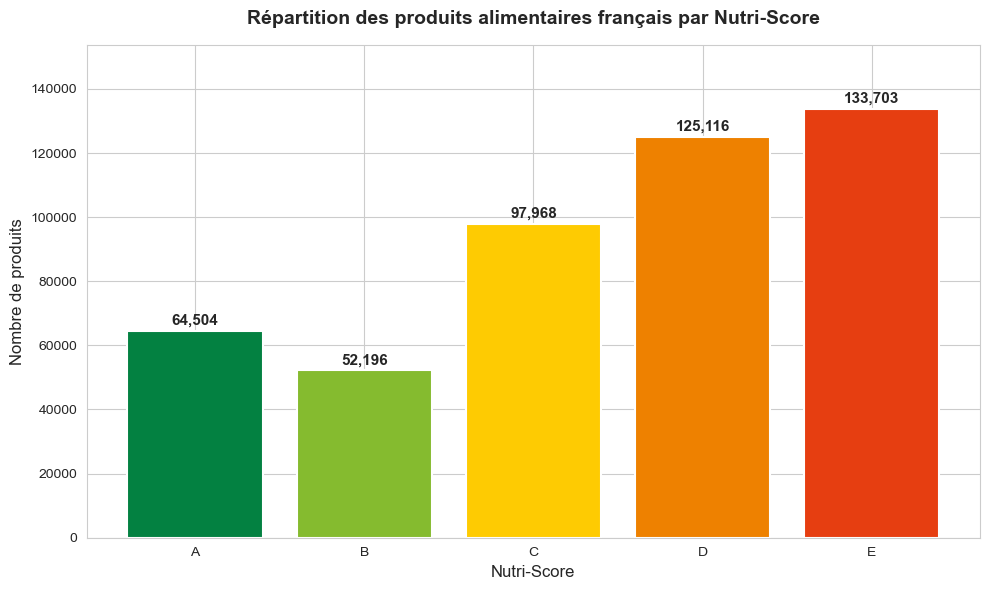

Graphique


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

couleurs_nutriscore = {
    'A': '#038141',  
    'B': '#85BB2F',  
    'C': '#FECB02', 
    'D': '#EE8100', 
    'E': '#E63E11'  
}
nutriscore_counts = df['nutriscore'].value_counts().reindex(['A','B','C','D','E'])

fig, ax = plt.subplots()
bars = ax.bar(
    nutriscore_counts.index,
    nutriscore_counts.values,
    color=[couleurs_nutriscore[n] for n in nutriscore_counts.index],
    edgecolor='white',
    linewidth=1.5
)

for bar, val in zip(bars, nutriscore_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Répartition des produits alimentaires français par Nutri-Score',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Nutri-Score', fontsize=12)
ax.set_ylabel('Nombre de produits', fontsize=12)
ax.set_ylim(0, nutriscore_counts.max() * 1.15)

plt.tight_layout()
plt.savefig(r"C:\econometrie2\projet S2\graph_nutriscore.png", dpi=150)
plt.show()
print("Graphique")

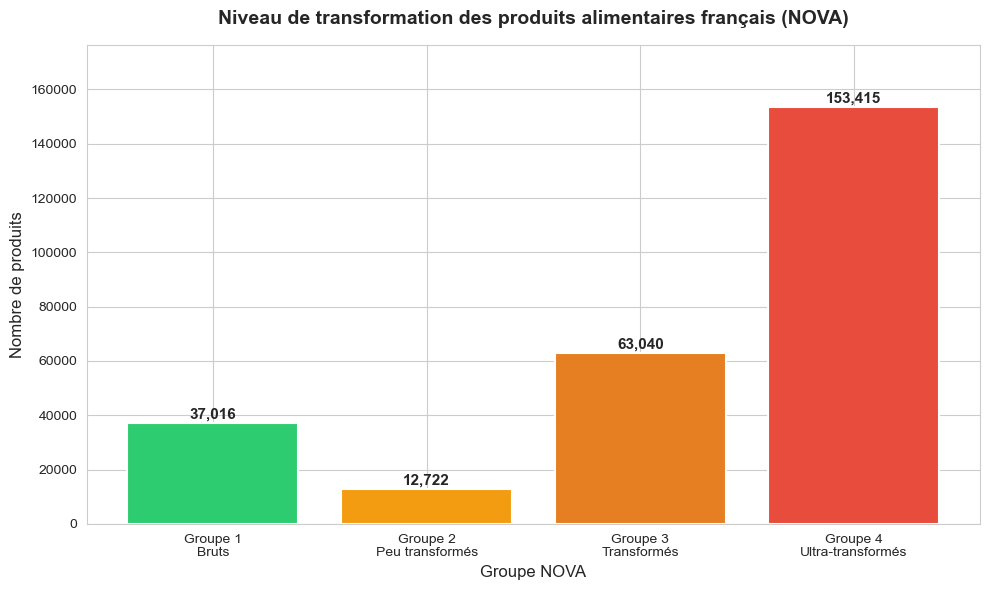

Graphique NOVA sauvegardé


In [7]:
# Graphique NOVA
couleurs_nova = {
    1: '#2ecc71',   # vert: aliments bruts
    2: '#f39c12',   # orange: peu transformés
    3: '#e67e22',   # orange foncé: transformés
    4: '#e74c3c'    # rouge: ultra-transformés
}

labels_nova = {
    1: 'Groupe 1\nBruts',
    2: 'Groupe 2\nPeu transformés',
    3: 'Groupe 3\nTransformés',
    4: 'Groupe 4\nUltra-transformés'
}

nova_counts = df['transformation'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    [labels_nova[i] for i in nova_counts.index],
    nova_counts.values,
    color=[couleurs_nova[i] for i in nova_counts.index],
    edgecolor='white',
    linewidth=1.5
)

for bar, val in zip(bars, nova_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title("Niveau de transformation des produits alimentaires français (NOVA)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Groupe NOVA', fontsize=12)
ax.set_ylabel('Nombre de produits', fontsize=12)
ax.set_ylim(0, nova_counts.max() * 1.15)

plt.tight_layout()
plt.savefig(r"C:\econometrie2\projet S2\graph_nova.png", dpi=150)
plt.show()
print("Graphique NOVA sauvegardé")

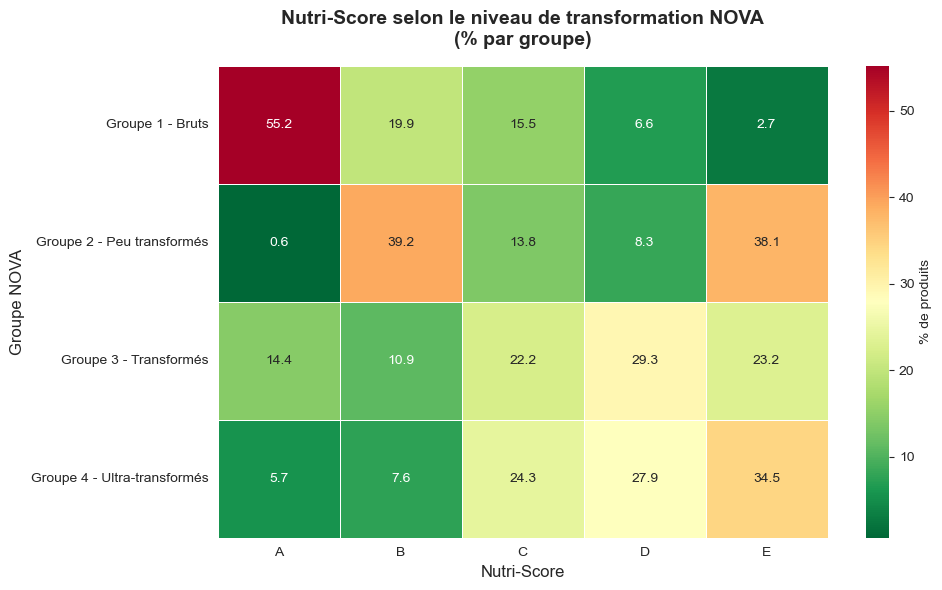

Heatmap sauvegardé


In [8]:
# Heatmap Nutri-Score x Transformation NOVA
df_heat = df.dropna(subset=['nutriscore', 'transformation'])

pivot = df_heat.groupby(
    ['transformation', 'nutriscore']
).size().unstack().reindex(columns=['A','B','C','D','E'])

# Convertir en pourcentage par ligne
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot_pct,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% de produits'}
)

ax.set_title('Nutri-Score selon le niveau de transformation NOVA\n(% par groupe)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Nutri-Score', fontsize=12)
ax.set_ylabel('Groupe NOVA', fontsize=12)
ax.set_yticklabels([
    'Groupe 1 - Bruts',
    'Groupe 2 - Peu transformés',
    'Groupe 3 - Transformés',
    'Groupe 4 - Ultra-transformés'
], rotation=0)

plt.tight_layout()
plt.savefig(r"C:\econometrie2\projet S2\graph_heatmap.png", dpi=150)
plt.show()
print("Heatmap sauvegardé")

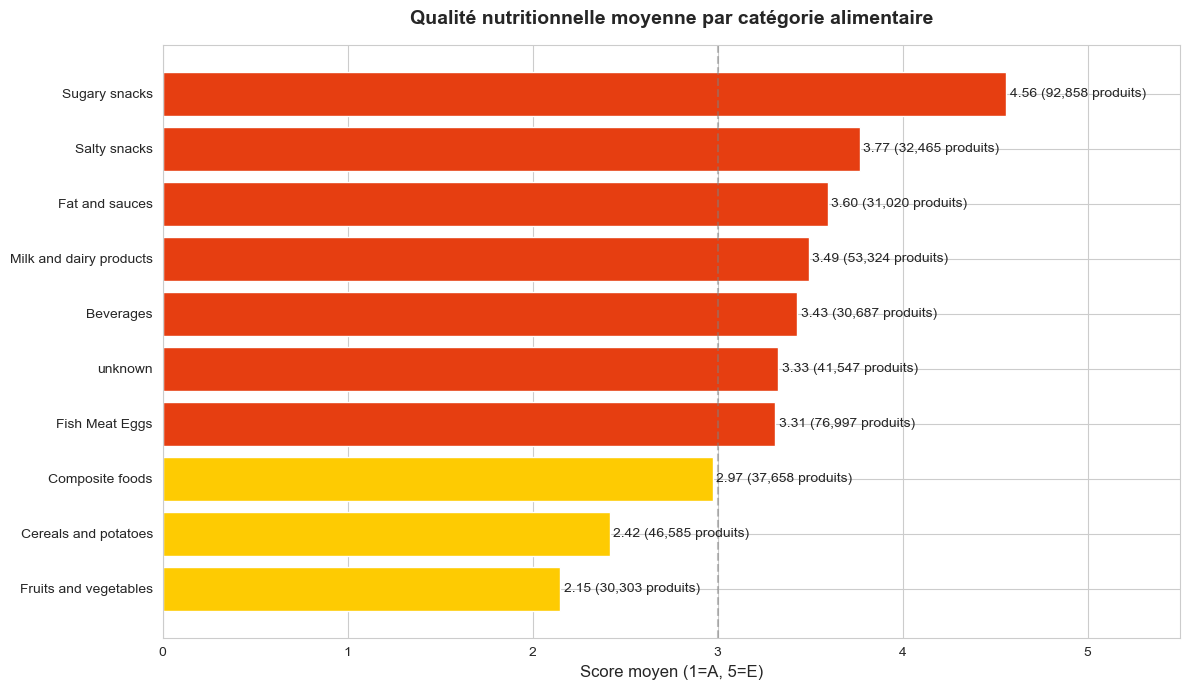

Graphique categories sauvegardé


In [9]:
# Top categories par nutriscore moyen
# On convertit nutriscore en valeur numérique
score_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}
df['nutriscore_num'] = df['nutriscore'].map(score_map)

# Garder les catégories avec au moins 500 produits
top_categories = (
    df.groupby('groupe_alimentaire_1')
    .agg(
        score_moyen=('nutriscore_num', 'mean'),
        nb_produits=('nutriscore_num', 'count')
    )
    .query('nb_produits >= 500')
    .sort_values('score_moyen')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))

couleurs = ['#038141' if s <= 2 else '#FECB02' if s <= 3 else '#E63E11'
            for s in top_categories['score_moyen']]

bars = ax.barh(
    top_categories['groupe_alimentaire_1'],
    top_categories['score_moyen'],
    color=couleurs,
    edgecolor='white'
)

for bar, val, nb in zip(bars,
                         top_categories['score_moyen'],
                         top_categories['nb_produits']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} ({nb:,} produits)',
            va='center', fontsize=10)

ax.set_xlim(0, 5.5)
ax.set_xlabel('Score moyen (1=A, 5=E)', fontsize=12)
ax.set_title('Qualité nutritionnelle moyenne par catégorie alimentaire',
             fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=3, color='gray', linestyle='--', alpha=0.5, label='Seuil C')

plt.tight_layout()
plt.savefig(r"C:\econometrie2\projet S2\graph_categories.png", dpi=150)
plt.show()
print("Graphique categories sauvegardé")

## 5. Correction des types numériques

In [ ]:
# Remplacer vides par 0 et convertir en entier
df['nb_scans'] = pd.to_numeric(df['nb_scans'], errors='coerce').fillna(0).astype(int)

print(df['nb_scans'].dtype)
print(df['nb_scans'].sort_values(ascending=False).head(5))

df.to_csv(r"C:\econometrie2\projet S2\projetalleger.csv", index=False, decimal='.')
print("OK")


int64
1049958    3410
1048498    2961
1048496    2397
1048511    2206
1051141    1945
Name: nb_scans, dtype: int64
